# 3.0 Modelado

Corresponde a la seccion 7.4 de la monografia. Tres partes, en orden:

1. **Comparacion inicial** de Baseline / Regresion Logistica / SVM /
   Random Forest sobre las 4 particiones originales y el dataset
   completo (994 ventanas) -- reproduce las Tablas 9-14 ya presentadas.
2. **Ajuste de hiperparametros** de Random Forest y SVM, comparando
   configuraciones explicitamente sobre el conjunto de ajuste (18
   archivos) -- responde a la observacion de justificar los
   hiperparametros en vez de fijarlos sin comparacion.
3. **Comparacion de los modelos ya ajustados**, tambien sobre el
   conjunto de ajuste, para decidir el modelo final ANTES de evaluar
   sobre el test independiente (eso se hace en 4.0).

Toda la logica vive en `rodamientos_module.modeling`; este notebook solo
la invoca y presenta los resultados.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
from rodamientos_module import config
from rodamientos_module.modeling import train as train_module

df_modelo_base = pd.read_csv(config.DIR_DATOS_PROCESSED / "tabla_modelado.csv")
df_ajuste = pd.read_csv(config.DIR_DATOS_PROCESSED / "conjunto_ajuste.csv")
df_test_final = pd.read_csv(config.DIR_DATOS_PROCESSED / "conjunto_test_final.csv")

print(f"Dataset completo: {len(df_modelo_base)} ventanas")
print(f"Conjunto de ajuste: {len(df_ajuste)} ventanas")
print(f"Conjunto de test final: {len(df_test_final)} ventanas")

Dataset completo: 994 ventanas
Conjunto de ajuste: 731 ventanas
Conjunto de test final: 263 ventanas


## 7.4.1 - 7.4.5 Comparacion inicial (dataset completo, 4 particiones)

Reproduce la comparacion original documentada en el cuerpo de la
monografia. Nota metodologica (respuesta a la observacion sobre las 994
ventanas): estas provienen de solo 24 registros independientes; la
validacion agrupa por archivo para no tratarlas como observaciones
independientes entre si.

In [2]:
resultados_iniciales = train_module.comparacion_inicial(df_modelo_base)

tabla_comparacion_inicial = pd.DataFrame([
    {"modelo": nombre, **resultado["promedio"].to_dict()}
    for nombre, resultado in resultados_iniciales.items()
])
tabla_comparacion_inicial.round(4)

,modelo,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro
0,Baseline,0.4084,0.2500,0.1021,0.2500,0.1441
1,Regresion Logistica,0.9716,0.9375,0.9215,0.9375,0.9283
2,SVM,0.9915,0.9812,0.9941,0.9812,0.9859
3,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000


### Figuras 8-10. Matrices de confusion (comparacion inicial, 4 particiones)

Matrices de confusion agregadas sobre las cuatro particiones originales
para Regresion Logistica, SVM y Random Forest (seccion 7.5.2).

--- Regresion Logistica ---
[[413   0   0   0]
 [  0 116   0   0]
 [  0   0  87  30]
 [  0   0   0 348]]


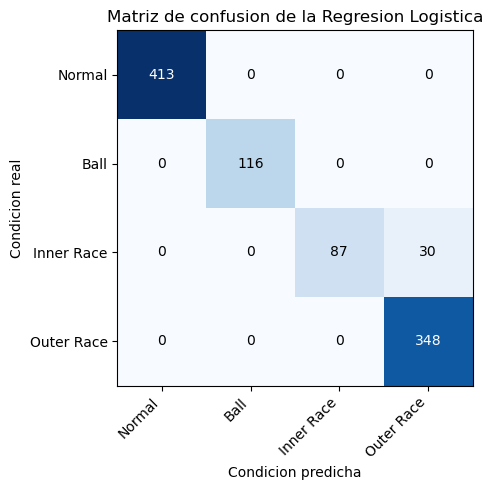

--- SVM ---
[[413   0   0   0]
 [  0 116   0   0]
 [  0   0 108   9]
 [  0   0   0 348]]


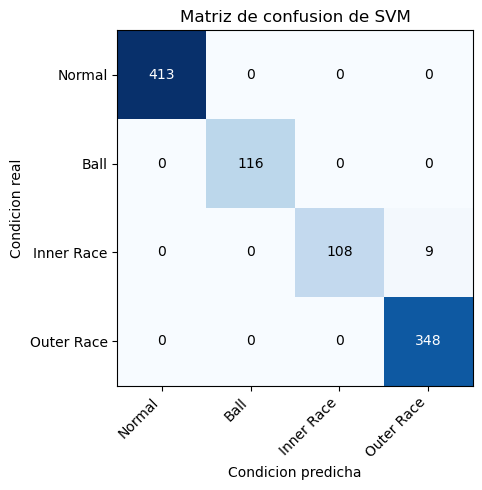

--- Random Forest ---
[[413   0   0   0]
 [  0 116   0   0]
 [  0   0 117   0]
 [  0   0   0 348]]


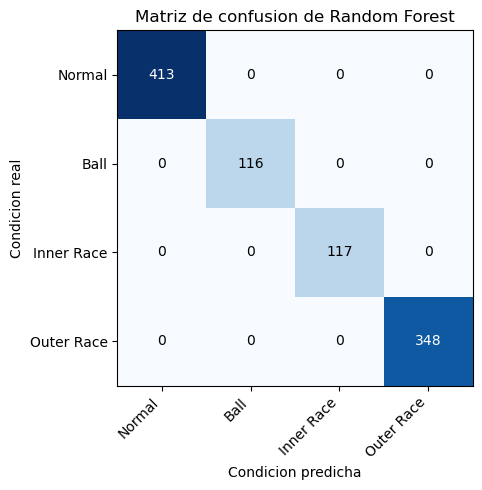

In [3]:
import matplotlib.pyplot as plt
from rodamientos_module.modeling.evaluator import Evaluador

evaluador = Evaluador(
    features=config.CARACTERISTICAS_MODELO,
    columna_clase=config.COLUMNA_CLASE,
    orden_clases=config.ORDEN_CLASES,
)


def graficar_matriz(matriz, titulo, ruta):
    fig, ax = plt.subplots(figsize=(5.5, 5))
    im = ax.imshow(matriz, cmap="Blues")
    ax.set_xticks(range(len(config.ORDEN_CLASES)))
    ax.set_yticks(range(len(config.ORDEN_CLASES)))
    ax.set_xticklabels(config.ORDEN_CLASES, rotation=45, ha="right")
    ax.set_yticklabels(config.ORDEN_CLASES)
    ax.set_xlabel("Condicion predicha")
    ax.set_ylabel("Condicion real")
    ax.set_title(titulo)
    vmax = matriz.max()
    for i in range(len(config.ORDEN_CLASES)):
        for j in range(len(config.ORDEN_CLASES)):
            color = "white" if matriz[i, j] > vmax / 2 else "black"
            ax.text(j, i, matriz[i, j], ha="center", va="center", color=color)
    plt.tight_layout()
    plt.savefig(ruta, dpi=150)
    plt.show()


nombre_archivo_figura = {
    "Regresion Logistica": ("../reports/figures/fig08_matriz_confusion_lr.png", "Matriz de confusion de la Regresion Logistica"),
    "SVM": ("../reports/figures/fig09_matriz_confusion_svm.png", "Matriz de confusion de SVM"),
    "Random Forest": ("../reports/figures/fig10_matriz_confusion_rf.png", "Matriz de confusion de Random Forest"),
}
for nombre, (ruta, titulo) in nombre_archivo_figura.items():
    matriz = evaluador.matriz_confusion(resultados_iniciales[nombre]["predicciones"])
    print(f"--- {nombre} ---")
    print(matriz)
    graficar_matriz(matriz, titulo, ruta)

### Figura 11. Importancia por permutacion de Random Forest (comparacion inicial)

Se calcula para cada una de las 4 particiones originales (10 repeticiones
por caracteristica) y se promedia, reproduciendo la Tabla 15 de la
seccion 7.5.3.

In [4]:
from sklearn.inspection import permutation_importance
from rodamientos_module.modeling.models import RandomForestModel
from rodamientos_module.particionado import ParticionadorPorArchivo

importancias_por_fold = []
for fold in config.FOLDS_ARCHIVOS_COMPLETOS:
    idx_train, idx_test = ParticionadorPorArchivo.indices_fold(df_modelo_base, config.FOLDS_ARCHIVOS_COMPLETOS, fold)
    X_train = df_modelo_base.loc[idx_train, config.CARACTERISTICAS_MODELO]
    y_train = df_modelo_base.loc[idx_train, config.COLUMNA_CLASE]
    X_test = df_modelo_base.loc[idx_test, config.CARACTERISTICAS_MODELO]
    y_test = df_modelo_base.loc[idx_test, config.COLUMNA_CLASE]

    modelo_rf = RandomForestModel(n_estimators=200, random_state=config.RANDOM_STATE).construir()
    modelo_rf.fit(X_train, y_train)
    imp = permutation_importance(
        modelo_rf, X_test, y_test, scoring="balanced_accuracy",
        n_repeats=10, random_state=config.RANDOM_STATE, n_jobs=-1,
    )
    for feat, media, desv in zip(config.CARACTERISTICAS_MODELO, imp.importances_mean, imp.importances_std):
        importancias_por_fold.append({"fold": fold, "caracteristica": feat, "importancia_media": media, "desviacion": desv})

df_importancias_rf = pd.DataFrame(importancias_por_fold)
resumen_importancia_rf = (
    df_importancias_rf.groupby("caracteristica")[["importancia_media", "desviacion"]]
    .mean().reindex(config.CARACTERISTICAS_MODELO).sort_values("importancia_media", ascending=False)
)
resumen_importancia_rf.to_csv("../reports/tabla_importancia_rf_comparacion_inicial.csv")
resumen_importancia_rf.round(4)

,importancia_media,desviacion
caracteristica,,
kurtosis,0.2857,0.0219
rms,0.1917,0.0231
centroide_espectral,0.0669,0.0114
skewness,0.0000,0.0000
factor_cresta,0.0000,0.0000


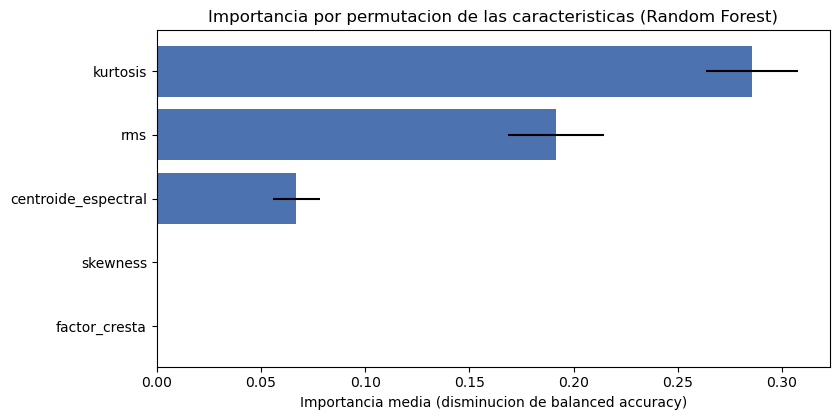

Figura guardada en reports/figures/fig11_importancia_rf.png


In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.barh(resumen_importancia_rf.index, resumen_importancia_rf["importancia_media"],
        xerr=resumen_importancia_rf["desviacion"], color="#4C72B0")
ax.set_xlabel("Importancia media (disminucion de balanced accuracy)")
ax.set_title("Importancia por permutacion de las caracteristicas (Random Forest)", fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/figures/fig11_importancia_rf.png", dpi=150)
plt.show()
print("Figura guardada en reports/figures/fig11_importancia_rf.png")

### Figura 12. RMS promedio por registro experimental

Verificacion adicional (seccion 7.5.5) del desempeno elevado observado:
se examina si existen diferencias sistematicas de RMS entre los 24
registros experimentales.

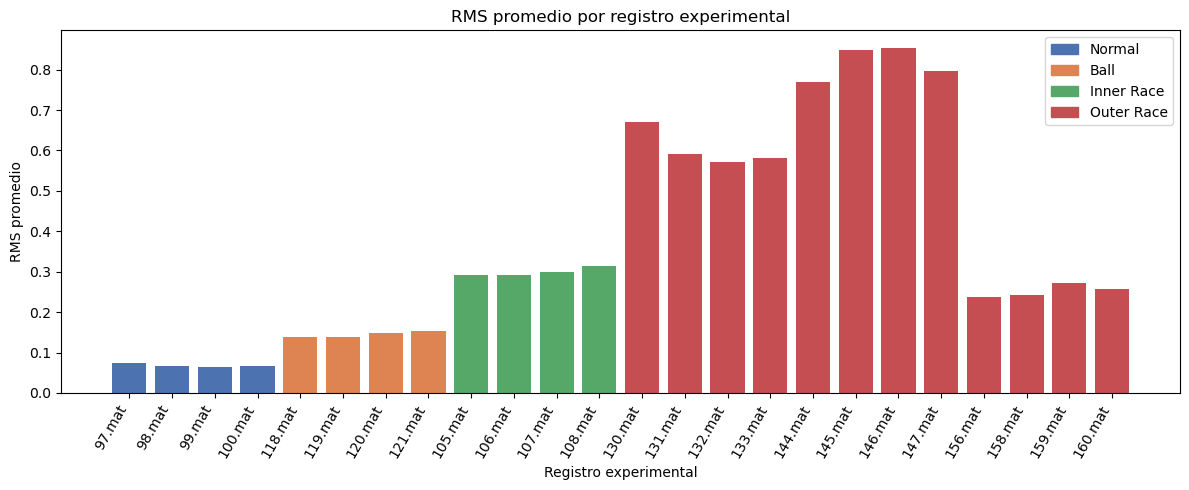

Figura guardada en reports/figures/fig12_rms_por_registro.png


In [6]:
tabla_desc = pd.read_csv(config.DIR_DATOS_INTERIM / "estadisticos_descriptivos.csv")
tabla_desc = tabla_desc.set_index("archivo").loc[
    [a for clase in config.ORDEN_CLASES for a in config.ARCHIVOS_POR_CLASE[clase]]
].reset_index()

colores_clase = {"Normal": "#4C72B0", "Ball": "#DD8452", "Inner Race": "#55A868", "Outer Race": "#C44E52"}
colores = [colores_clase[c] for c in tabla_desc["clase"]]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(tabla_desc["archivo"], tabla_desc["rms"], color=colores)
ax.set_ylabel("RMS promedio")
ax.set_xlabel("Registro experimental")
ax.set_title("RMS promedio por registro experimental")
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
handles = [plt.Rectangle((0, 0), 1, 1, color=colores_clase[c]) for c in config.ORDEN_CLASES]
ax.legend(handles, config.ORDEN_CLASES)
plt.tight_layout()
plt.savefig("../reports/figures/fig12_rms_por_registro.png", dpi=150)
plt.show()
print("Figura guardada en reports/figures/fig12_rms_por_registro.png")

## 7.4.x Ajuste de hiperparametros (SOLO conjunto de ajuste)

Se comparan 5 configuraciones de Random Forest (variando `n_estimators` y
`max_depth`) y 4 configuraciones de SVM (kernel lineal vs. RBF, distintos
valores de `C`), usando las 3 particiones del conjunto de ajuste. El
conjunto de test final no participa en ningun momento de esta
comparacion.

In [7]:
tabla_rf_hiperparametros, tabla_svm_hiperparametros, mejor_rf, mejor_svm = (
    train_module.ajustar_hiperparametros(df_ajuste)
)

print("=== Comparacion de configuraciones - Random Forest ===")
tabla_rf_hiperparametros.round(4)

=== Comparacion de configuraciones - Random Forest ===


,n_estimators,max_depth,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro
0,50,NaN,0.7799,0.8333,0.6976,0.8333,0.7286
1,100,NaN,0.7799,0.8333,0.6924,0.8333,0.7259
2,200,NaN,0.7799,0.8333,0.6940,0.8333,0.7267
3,200,5.0,0.7799,0.8333,0.6940,0.8333,0.7267
4,200,10.0,0.7799,0.8333,0.6940,0.8333,0.7267


In [8]:
print("=== Comparacion de configuraciones - SVM ===")
tabla_svm_hiperparametros.round(4)

=== Comparacion de configuraciones - SVM ===


,kernel,C,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro
0,linear,1.0,0.7824,0.8352,0.7926,0.8352,0.7382
1,rbf,0.1,0.9949,0.9962,0.9902,0.9962,0.9928
2,rbf,1.0,0.9836,0.9875,0.9780,0.9875,0.9810
3,rbf,10.0,0.9836,0.9875,0.9780,0.9875,0.9810


In [9]:
print(f"Mejor configuracion Random Forest (segun balanced accuracy): {mejor_rf}")
print(f"Mejor configuracion SVM (segun balanced accuracy): {mejor_svm}")

Mejor configuracion Random Forest (segun balanced accuracy): {'n_estimators': 50, 'max_depth': None}
Mejor configuracion SVM (segun balanced accuracy): {'kernel': 'rbf', 'C': np.float64(0.1)}


**Nota para el informe (reemplaza el parrafo de 7.4.4 sobre `n_estimators=200`
sin justificacion, y el de 7.4.3 sobre SVM con RBF sin ajuste):**

> *"Se compararon distintas configuraciones de Random Forest y SVM sobre
> el conjunto de ajuste (18 archivos, 3 particiones agrupadas por
> archivo experimental). Para Random Forest, la configuracion
> `n_estimators={n_est}, max_depth={depth}` obtuvo el mejor balanced
> accuracy promedio. Para SVM, la configuracion `kernel={kernel}, C={C}`
> obtuvo el mejor resultado. Ambas configuraciones fueron seleccionadas
> para los modelos finales."*

Completar `{n_est}`, `{depth}`, `{kernel}`, `{C}` con los valores
impresos en la celda anterior.

## Comparacion de los modelos ya ajustados (conjunto de ajuste)

Con los hiperparametros ya justificados, se compara Baseline / Regresion
Logistica / SVM (ajustado) / Random Forest (ajustado) sobre el conjunto
de ajuste. El modelo con mejor desempeno aqui es el que se evalua una
unica vez sobre el test independiente, en el notebook 4.0.

In [10]:
tabla_comparacion_ajuste, modelos_ajustados = train_module.comparar_modelos_ajustados(
    df_ajuste, mejor_rf, mejor_svm
)
tabla_comparacion_ajuste.round(4)

,modelo,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro
0,Baseline,0.3950,0.2500,0.0987,0.2500,0.1405
1,Regresion Logistica,0.7673,0.7763,0.7254,0.7763,0.7272
2,SVM (ajustado),0.9949,0.9962,0.9902,0.9962,0.9928
3,Random Forest (ajustado),0.7799,0.8333,0.6976,0.8333,0.7286


In [11]:
mejor_modelo_nombre = tabla_comparacion_ajuste.loc[
    tabla_comparacion_ajuste["balanced_accuracy"].idxmax(), "modelo"
]
print(f"Modelo seleccionado para evaluacion final: {mejor_modelo_nombre}")

Modelo seleccionado para evaluacion final: SVM (ajustado)


### Guardado de resultados intermedios

Se guardan las tablas de comparacion y el nombre del modelo seleccionado,
para que el notebook 4.0 (evaluacion) los retome sin tener que rehacer el
ajuste de hiperparametros.

In [12]:
import joblib

tabla_comparacion_inicial.to_csv(config.DIR_REPORTES_FIGURAS.parent / "tabla_comparacion_inicial.csv", index=False)
tabla_rf_hiperparametros.to_csv(config.DIR_REPORTES_FIGURAS.parent / "tabla_rf_hiperparametros.csv", index=False)
tabla_svm_hiperparametros.to_csv(config.DIR_REPORTES_FIGURAS.parent / "tabla_svm_hiperparametros.csv", index=False)
tabla_comparacion_ajuste.to_csv(config.DIR_REPORTES_FIGURAS.parent / "tabla_comparacion_ajuste.csv", index=False)

joblib.dump(
    {"mejor_rf": mejor_rf, "mejor_svm": mejor_svm, "modelo_seleccionado": mejor_modelo_nombre},
    config.DIR_MODELOS / "seleccion_hiperparametros.pkl",
)
print("Resultados de 3.0 guardados en reports/ y models/")

Resultados de 3.0 guardados en reports/ y models/
